
# Proyecto VRCE

## Índice:

1) Introducción
2) Objetivo
3) Análisis Exploratorio de Datos
4) Limpieza y Preprocesamiento
5) Ingeniería de Features
6) Selección de Variables
7) Entrenamiento
8) Evaluación

## 1. Introducción

Se analiza la estructura inicial del repositorio de datos utilizado en el proyecto Valorant Role Compliance Evaluation (VRCE), cuyo objetivo es desarrollar un sistema de inteligencia artificial capaz de evaluar el rendimiento individual de jugadores profesionales de Valorant.

Los datos no se encuentran consolidados en un único dataset listo para el análisis. En su lugar, el repositorio está organizado siguiendo una lógica similar a la de un data lake, donde la información se almacena de forma distribuida y segmentada por temporadas competitivas. Dentro de la carpeta principal /data existen distintas particiones anuales (vct_2021, vct_2022, ..., vct_2025) que contienen información específica de cada periodo, así como una carpeta global /all_ids que actúa como catálogo de identificadores del ecosistema competitivo.

Cada partición anual se divide a su vez en subcarpetas que representan diferentes tipos de información, como agents, ids, matches y player_stats, lo que permite separar las entidades principales del sistema competitivo. Esta organización facilita el almacenamiento histórico de los datos, aunque implica que el dataset final aún no está completamente consolidado y requiere procesos posteriores de integración y preparación antes de ser utilizado para modelado.

## 2. Objetivo

El objetivo de esta exploración inicial es comprender la organización del data lake y el papel de cada uno de sus componentes antes de realizar el análisis de datos. En particular, se busca identificar la estructura del repositorio, los diferentes tipos de archivos disponibles y cómo se relacionan entre sí las entidades principales del sistema competitivo, como jugadores, equipos, partidas y torneos.

Esta etapa es fundamental para establecer una base sólida para el análisis exploratorio de datos (EDA), ya que permitirá determinar qué fuentes contienen la información relevante para el proyecto, cómo deben integrarse los distintos conjuntos de datos y cuál será la unidad de análisis más adecuada para evaluar el rendimiento competitivo de los jugadores.

## 3. Análisis Exploratorio de Datos

### 1) Importación de librerías

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA

# Configuración visual

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

### 2) Definir las rutas del Data Lake

In [2]:
# Los CSV están en la misma carpeta que el notebook
DATA_PATH = "data/vct_2025"

player_stats_path = os.path.join(DATA_PATH, "players_stats")

### 3) Cargar dataset

In [3]:
# Player stats (dataset principal)
player_stats = pd.read_csv(os.path.join(player_stats_path, "players_stats.csv"))

# Ver primeras filas
player_stats.head()

,Tournament,Stage,Match Type,Player,Teams,Agents,Rounds Played,Rating,Average Combat Score,Kills:Deaths,...,First Deaths Per Round,Headshot %,Clutch Success %,Clutches (won/played),Maximum Kills in a Single Map,Kills,Deaths,Assists,First Kills,First Deaths
0,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,astra,26,0.68,129.0,0.61,...,0.12,44%,NaN,0/4,11,11,18,4,3,3
1,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,omen,19,0.46,98.0,0.40,...,0.26,37%,33%,1/3,6,6,15,5,1,5
2,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,"astra, omen",45,0.59,114.0,0.52,...,0.18,41%,14%,1/7,11,17,33,9,4,8
3,Valorant Champions 2025,Playoffs,Upper Quarterfinals,RieNs,Team Heretics,fade,26,1.21,219.0,1.13,...,0.04,23%,33%,1/3,18,18,16,10,2,1
4,Valorant Champions 2025,Playoffs,Upper Quarterfinals,RieNs,Team Heretics,sova,19,1.02,220.0,0.75,...,0.05,28%,NaN,0/4,12,12,16,5,1,1


In [4]:
# Dimensiones del dataset
print(f"Filas: {player_stats.shape[0]}")
print(f"Columnas: {player_stats.shape[1]}")

Filas: 17996
Columnas: 25


In [5]:
# Columnas originales
player_stats.columns.tolist()

['Tournament',
 'Stage',
 'Match Type',
 'Player',
 'Teams',
 'Agents',
 'Rounds Played',
 'Rating',
 'Average Combat Score',
 'Kills:Deaths',
 'Kill, Assist, Trade, Survive %',
 'Average Damage Per Round',
 'Kills Per Round',
 'Assists Per Round',
 'First Kills Per Round',
 'First Deaths Per Round',
 'Headshot %',
 'Clutch Success %',
 'Clutches (won/played)',
 'Maximum Kills in a Single Map',
 'Kills',
 'Deaths',
 'Assists',
 'First Kills',
 'First Deaths']

In [6]:
# Información general del dataset
player_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Tournament                      17996 non-null  object 
 1   Stage                           17996 non-null  object 
 2   Match Type                      17996 non-null  object 
 3   Player                          17996 non-null  object 
 4   Teams                           17996 non-null  object 
 5   Agents                          17996 non-null  object 
 6   Rounds Played                   17996 non-null  int64  
 7   Rating                          16604 non-null  float64
 8   Average Combat Score            17986 non-null  float64
 9   Kills:Deaths                    17996 non-null  float64
 10  Kill, Assist, Trade, Survive %  16692 non-null  object 
 11  Average Damage Per Round        16626 non-null  float64
 12  Kills Per Round                 

In [7]:
# Estadísticas descriptivas iniciales
player_stats.describe(include="all")

,Tournament,Stage,Match Type,Player,Teams,Agents,Rounds Played,Rating,Average Combat Score,Kills:Deaths,...,First Deaths Per Round,Headshot %,Clutch Success %,Clutches (won/played),Maximum Kills in a Single Map,Kills,Deaths,Assists,First Kills,First Deaths
count,17996,17996,17996,17996,17996,17996,17996.000000,16604.000000,17986.000000,17996.000000,...,16646.000000,16688,6659,13263,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000,17996.000000
unique,15,5,37,313,58,1001,NaN,NaN,NaN,NaN,...,NaN,70,52,440,NaN,NaN,NaN,NaN,NaN,NaN
top,VCT 2025: Pacific Stage 1,Group Stage,All Match Types,Alfajer,Team Liquid,omen,NaN,NaN,NaN,NaN,...,NaN,26%,33%,0/1,NaN,NaN,NaN,NaN,NaN,NaN
freq,1583,6926,4291,151,701,1319,NaN,NaN,NaN,NaN,...,NaN,911,793,1495,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,56.905979,0.988747,195.649283,1.036644,...,0.101812,NaN,NaN,NaN,16.917648,39.377195,39.402367,16.060736,5.273727,5.281118
std,NaN,NaN,NaN,NaN,NaN,NaN,73.473854,0.275065,49.065678,0.451347,...,0.068724,NaN,NaN,NaN,5.739903,52.716300,50.380248,23.288620,8.685712,8.120614
min,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,0.030000,22.000000,0.000000,...,0.000000,NaN,NaN,NaN,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,22.000000,0.820000,163.000000,0.770000,...,0.050000,NaN,NaN,NaN,13.000000,15.000000,15.000000,5.000000,1.000000,1.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,37.000000,0.980000,193.000000,0.980000,...,0.090000,NaN,NaN,NaN,17.000000,24.000000,24.000000,9.000000,3.000000,3.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,61.000000,1.150000,225.000000,1.210000,...,0.140000,NaN,NaN,NaN,21.000000,41.000000,41.000000,17.000000,6.000000,6.000000


### 4) INSPECCIÓN DE CALIDAD DE DATOS

In [8]:
# Valores nulos por columna
missing_values = player_stats.isnull().sum().sort_values(ascending=False)
missing_values

Clutch Success %                  11337
Clutches (won/played)              4733
Rating                             1392
Average Damage Per Round           1370
First Kills Per Round              1351
First Deaths Per Round             1350
Headshot %                         1308
Kill, Assist, Trade, Survive %     1304
Average Combat Score                 10
Agents                                0
Rounds Played                         0
Player                                0
Teams                                 0
Match Type                            0
Stage                                 0
Tournament                            0
Kills:Deaths                          0
Assists Per Round                     0
Kills Per Round                       0
Maximum Kills in a Single Map         0
Kills                                 0
Deaths                                0
Assists                               0
First Kills                           0
First Deaths                          0


In [9]:
# Porcentaje de valores nulos
missing_percentage = (player_stats.isnull().mean() * 100).sort_values(ascending=False)
missing_percentage

Clutch Success %                  62.997333
Clutches (won/played)             26.300289
Rating                             7.735052
Average Damage Per Round           7.612803
First Kills Per Round              7.507224
First Deaths Per Round             7.501667
Headshot %                         7.268282
Kill, Assist, Trade, Survive %     7.246055
Average Combat Score               0.055568
Agents                             0.000000
Rounds Played                      0.000000
Player                             0.000000
Teams                              0.000000
Match Type                         0.000000
Stage                              0.000000
Tournament                         0.000000
Kills:Deaths                       0.000000
Assists Per Round                  0.000000
Kills Per Round                    0.000000
Maximum Kills in a Single Map      0.000000
Kills                              0.000000
Deaths                             0.000000
Assists                         

In [10]:
# Duplicados
duplicados = player_stats.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 0


In [11]:
# Tipos de datos originales
player_stats.dtypes

Tournament                         object
Stage                              object
Match Type                         object
Player                             object
Teams                              object
Agents                             object
Rounds Played                       int64
Rating                            float64
Average Combat Score              float64
Kills:Deaths                      float64
Kill, Assist, Trade, Survive %     object
Average Damage Per Round          float64
Kills Per Round                   float64
Assists Per Round                 float64
First Kills Per Round             float64
First Deaths Per Round            float64
Headshot %                         object
Clutch Success %                   object
Clutches (won/played)              object
Maximum Kills in a Single Map       int64
Kills                               int64
Deaths                              int64
Assists                             int64
First Kills                       

## 4. Limpieza y Preprocesamiento

### 1) LIMPIEZA Y CORRECCIÓN DE TIPOS

In [12]:
# Copia de trabajo
df_clean = player_stats.copy()

In [13]:
# Función para limpiar porcentajes
def clean_percentage(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        return float(value.replace("%", "").strip())
    return value

In [14]:
# Convertir columnas porcentuales
percentage_columns = [
    "Kill, Assist, Trade, Survive %",
    "Headshot %",
    "Clutch Success %"
]

for col in percentage_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_percentage)

In [15]:
# Convertir columnas numéricas
numeric_columns = [
    "Rounds Played",
    "Rating",
    "Average Combat Score",
    "Kills:Deaths",
    "Average Damage Per Round",
    "Kills Per Round",
    "Assists Per Round",
    "First Kills Per Round",
    "First Deaths Per Round",
    "Headshot %",
    "Clutch Success %",
    "Maximum Kills in a Single Map",
    "Kills",
    "Deaths",
    "Assists",
    "First Kills",
    "First Deaths"
]

for col in numeric_columns:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

In [16]:
# Procesar columna Clutches (won/played)
def extract_clutches_won(value):
    if pd.isna(value):
        return 0
    try:
        return int(str(value).split("/")[0])
    except:
        return 0

def extract_clutches_played(value):
    if pd.isna(value):
        return 0
    try:
        return int(str(value).split("/")[1])
    except:
        return 0

if "Clutches (won/played)" in df_clean.columns:
    df_clean["Clutches_Won"] = df_clean["Clutches (won/played)"].apply(extract_clutches_won)
    df_clean["Clutches_Played"] = df_clean["Clutches (won/played)"].apply(extract_clutches_played)

In [17]:
# Calcular ratio de clutch
df_clean["Clutch_Success_Ratio"] = np.where(
    df_clean["Clutches_Played"] > 0,
    df_clean["Clutches_Won"] / df_clean["Clutches_Played"],
    0
)

In [18]:
# Calcular KDR
df_clean["KDR"] = np.where(
    df_clean["Deaths"] > 0,
    df_clean["Kills"] / df_clean["Deaths"],
    df_clean["Kills"]
)

In [19]:
# Revisión posterior a la limpieza
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Tournament                      17996 non-null  object 
 1   Stage                           17996 non-null  object 
 2   Match Type                      17996 non-null  object 
 3   Player                          17996 non-null  object 
 4   Teams                           17996 non-null  object 
 5   Agents                          17996 non-null  object 
 6   Rounds Played                   17996 non-null  int64  
 7   Rating                          16604 non-null  float64
 8   Average Combat Score            17986 non-null  float64
 9   Kills:Deaths                    17996 non-null  float64
 10  Kill, Assist, Trade, Survive %  16692 non-null  float64
 11  Average Damage Per Round        16626 non-null  float64
 12  Kills Per Round                 

In [20]:
df_clean.head()

,Tournament,Stage,Match Type,Player,Teams,Agents,Rounds Played,Rating,Average Combat Score,Kills:Deaths,...,Maximum Kills in a Single Map,Kills,Deaths,Assists,First Kills,First Deaths,Clutches_Won,Clutches_Played,Clutch_Success_Ratio,KDR
0,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,astra,26,0.68,129.0,0.61,...,11,11,18,4,3,3,0,4,0.000000,0.611111
1,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,omen,19,0.46,98.0,0.40,...,6,6,15,5,1,5,1,3,0.333333,0.400000
2,Valorant Champions 2025,Playoffs,Upper Quarterfinals,Boo,Team Heretics,"astra, omen",45,0.59,114.0,0.52,...,11,17,33,9,4,8,1,7,0.142857,0.515152
3,Valorant Champions 2025,Playoffs,Upper Quarterfinals,RieNs,Team Heretics,fade,26,1.21,219.0,1.13,...,18,18,16,10,2,1,1,3,0.333333,1.125000
4,Valorant Champions 2025,Playoffs,Upper Quarterfinals,RieNs,Team Heretics,sova,19,1.02,220.0,0.75,...,12,12,16,5,1,1,0,4,0.000000,0.750000


### 2) MAPEO DE AGENTES A ROLES

In [21]:
df_clean["Agents"] = df_clean["Agents"].astype(str)

# separar múltiples agentes
df_clean["Agents"] = df_clean["Agents"].str.split(",").str[0].str.strip()

In [22]:
agent_to_role = {
    "Jett": "Duelist", "Raze": "Duelist", "Reyna": "Duelist",
    "Phoenix": "Duelist", "Yoru": "Duelist", "Neon": "Duelist",
    "Iso": "Duelist", "Waylay": "Duelist",          # ← Waylay agregado

    "Brimstone": "Controller", "Omen": "Controller",
    "Viper": "Controller", "Astra": "Controller", "Harbor": "Controller",
    "Clove": "Controller",

    "Sage": "Sentinel", "Cypher": "Sentinel",
    "Killjoy": "Sentinel", "Chamber": "Sentinel",
    "Deadlock": "Sentinel", "Vyse": "Sentinel",

    "Sova": "Initiator", "Breach": "Initiator",
    "Skye": "Initiator", "Kayo": "Initiator",       # ← KAY/O como "Kayo" por el .title()
    "Fade": "Initiator", "Gekko": "Initiator",
    "Tejo": "Initiator"
}

# Agentes y roles
df_clean["Agents"] = df_clean["Agents"].astype(str).str.split(",").str[0].str.strip().str.title()

df_clean["Role"] = df_clean["Agents"].map(agent_to_role)

In [23]:
df_clean[["Agents", "Role"]].head()

,Agents,Role
0,Astra,Controller
1,Omen,Controller
2,Astra,Controller
3,Fade,Initiator
4,Sova,Initiator


In [24]:
# Revisar roles generados
df_clean["Role"].value_counts()

Role
Initiator     5454
Controller    4696
Duelist       4066
Sentinel      3780
Name: count, dtype: int64

In [25]:
# Eliminar registros sin rol reconocido
df_clean = df_clean[df_clean["Role"] != "Unknown"].copy()

df_clean["Role"].value_counts()

Role
Initiator     5454
Controller    4696
Duelist       4066
Sentinel      3780
Name: count, dtype: int64

### 3) ANÁLISIS EXPLORATORIO DE DATOS

In [26]:
# Estadísticas descriptivas de variables numéricas relevantes
eda_columns = [
    "Average Combat Score",
    "Average Damage Per Round",
    "Kills Per Round",
    "Assists Per Round",
    "First Kills Per Round",
    "First Deaths Per Round",
    "Headshot %",
    "Clutch Success %",
    "Clutch_Success_Ratio",
    "Clutches_Won",
    "KDR"
]

df_clean[eda_columns].describe()

,Average Combat Score,Average Damage Per Round,Kills Per Round,Assists Per Round,First Kills Per Round,First Deaths Per Round,Headshot %,Clutch Success %,Clutch_Success_Ratio,Clutches_Won,KDR
count,17986.000000,16626.000000,17996.000000,17996.000000,16645.000000,16646.000000,16688.000000,6659.000000,17996.000000,17996.000000,17996.000000
mean,195.649283,128.316312,0.688337,0.279657,0.099878,0.101812,29.061182,30.130350,0.111514,0.724216,1.036515
std,49.065678,30.629254,0.192783,0.147140,0.071383,0.068724,8.482133,22.211479,0.198591,1.462399,0.451332
min,22.000000,20.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000
25%,163.000000,108.000000,0.560000,0.170000,0.050000,0.050000,23.000000,15.000000,0.000000,0.000000,0.772727
50%,193.000000,127.000000,0.680000,0.260000,0.090000,0.090000,28.000000,25.000000,0.000000,0.000000,0.980392
75%,225.000000,146.000000,0.800000,0.360000,0.140000,0.140000,34.000000,33.000000,0.166667,1.000000,1.208333
max,509.000000,307.000000,1.950000,1.570000,0.500000,0.530000,80.000000,100.000000,1.000000,28.000000,18.000000


In [27]:
# Distribución de roles
role_counts = df_clean["Role"].value_counts()
role_counts

Role
Initiator     5454
Controller    4696
Duelist       4066
Sentinel      3780
Name: count, dtype: int64

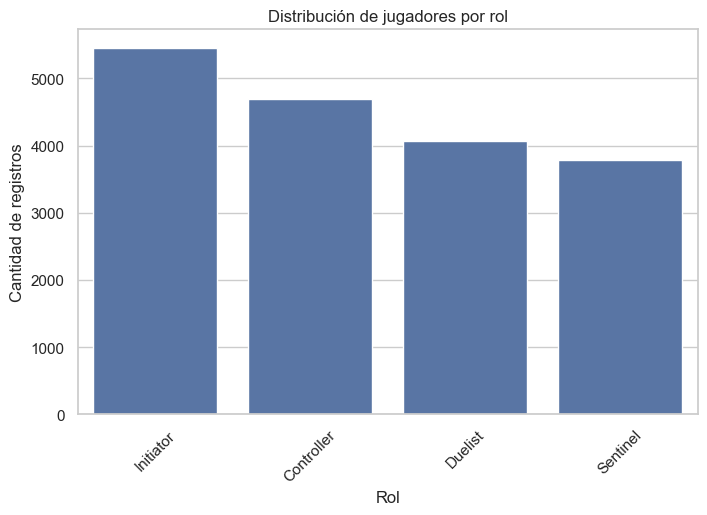

In [28]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="Role", order=role_counts.index)
plt.title("Distribución de jugadores por rol")
plt.xlabel("Rol")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.show()

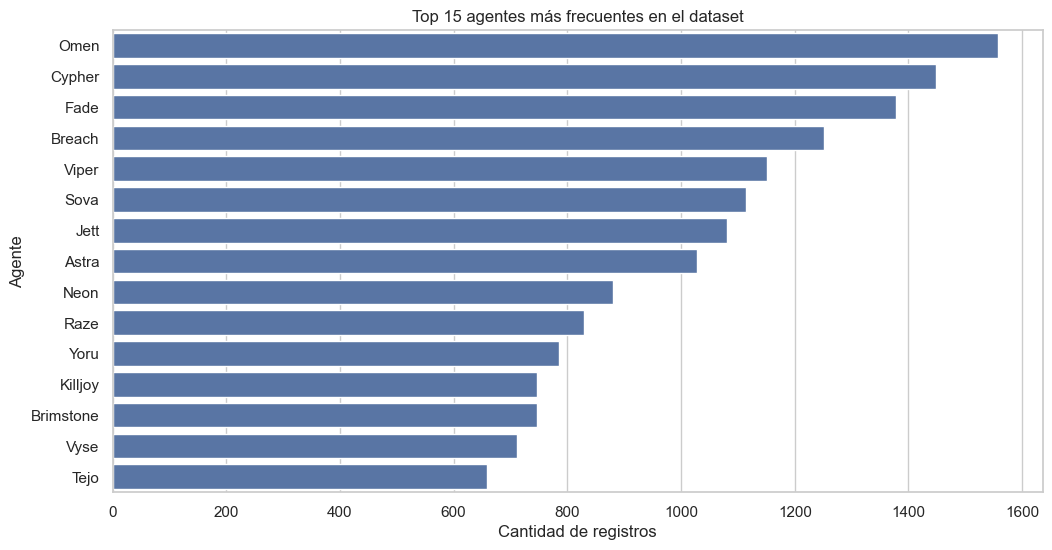

In [29]:
# Distribución de agentes más frecuentes
top_agents = df_clean["Agents"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_agents.values, y=top_agents.index)
plt.title("Top 15 agentes más frecuentes en el dataset")
plt.xlabel("Cantidad de registros")
plt.ylabel("Agente")
plt.show()

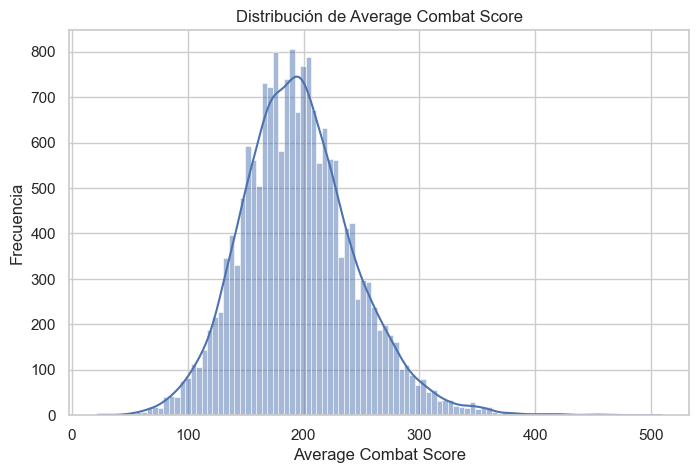

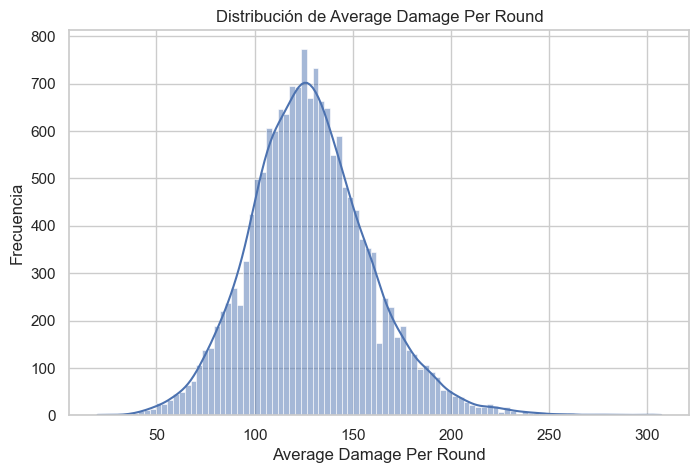

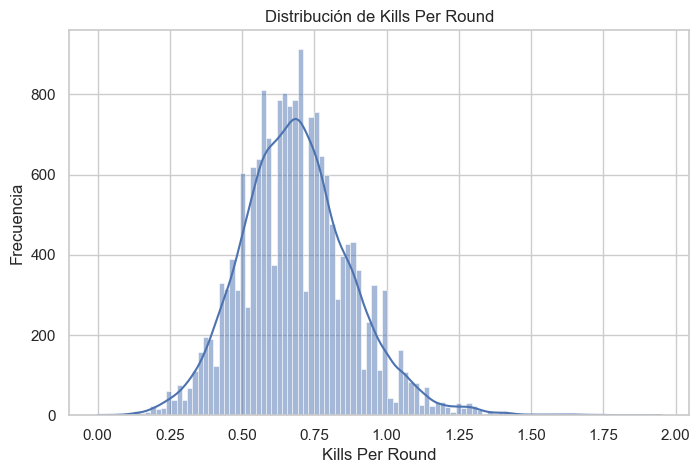

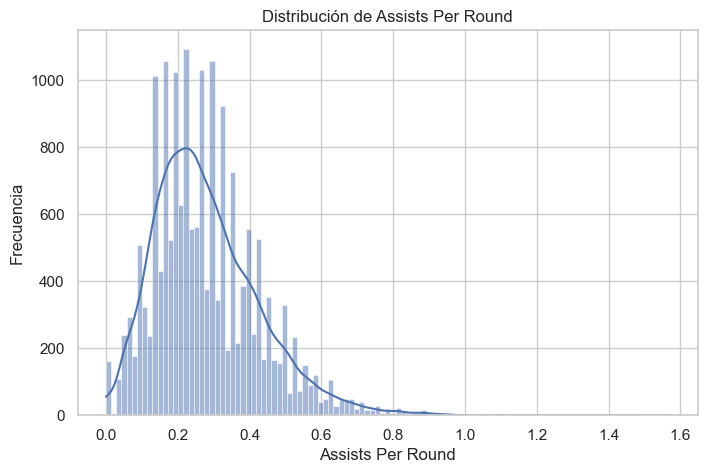

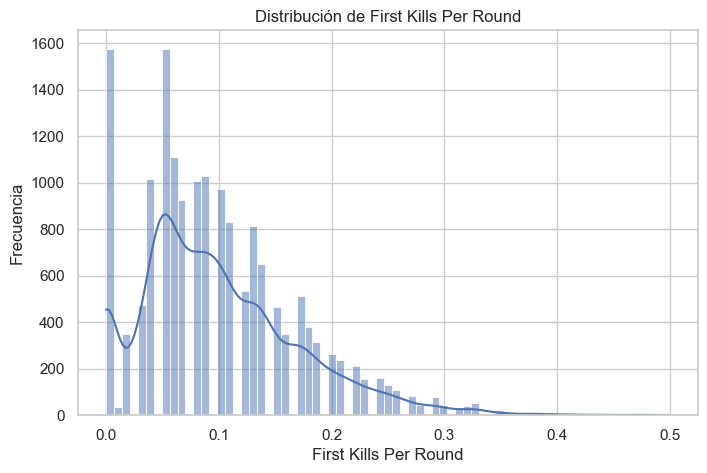

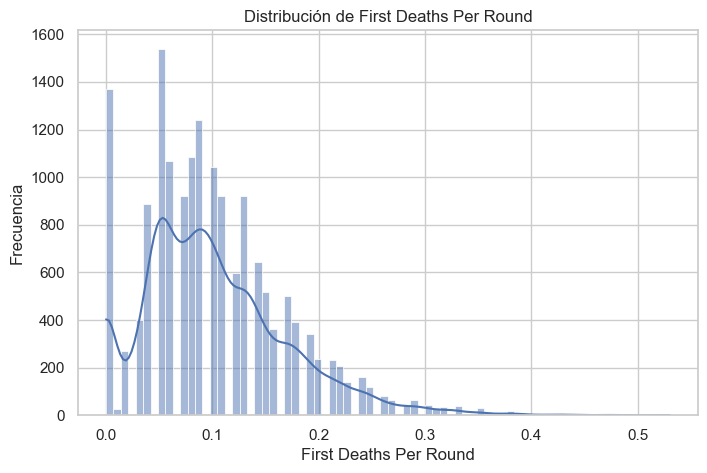

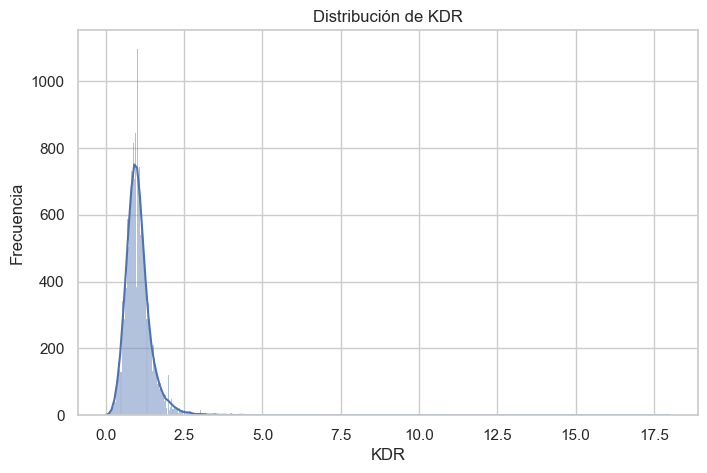

In [30]:
# Histogramas de variables clave
for col in [
    "Average Combat Score",
    "Average Damage Per Round",
    "Kills Per Round",
    "Assists Per Round",
    "First Kills Per Round",
    "First Deaths Per Round",
    "KDR"
]:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_clean[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

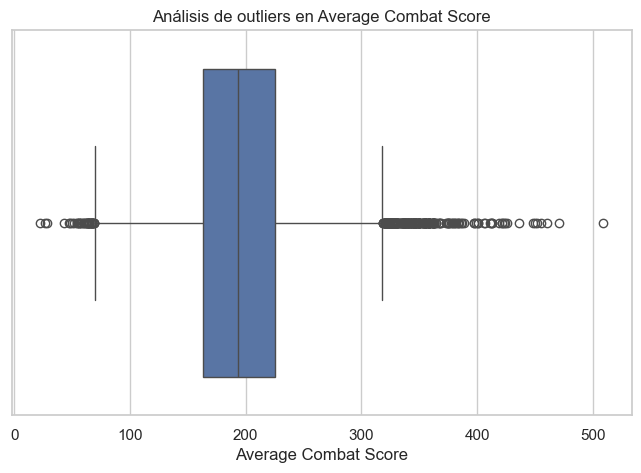

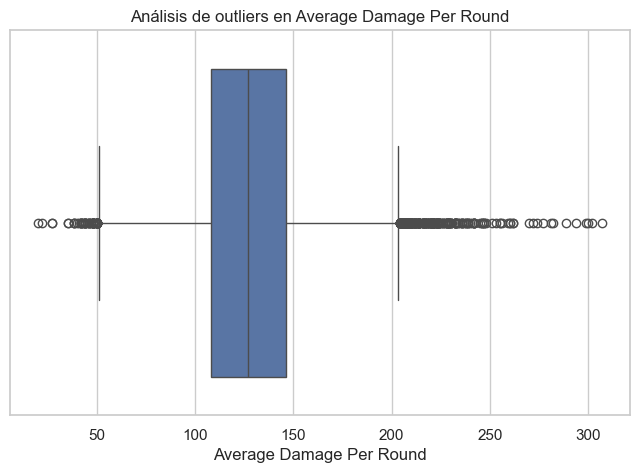

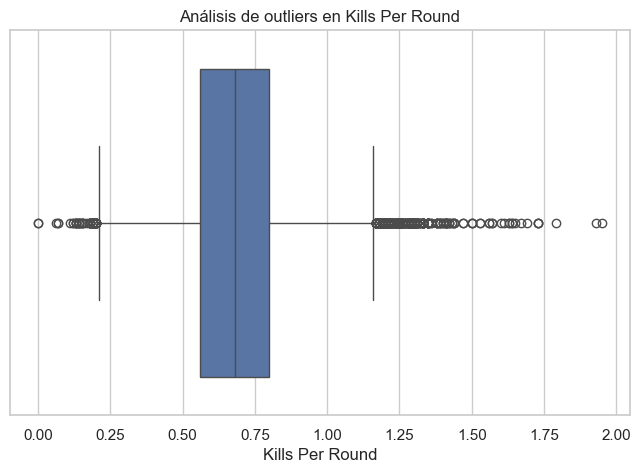

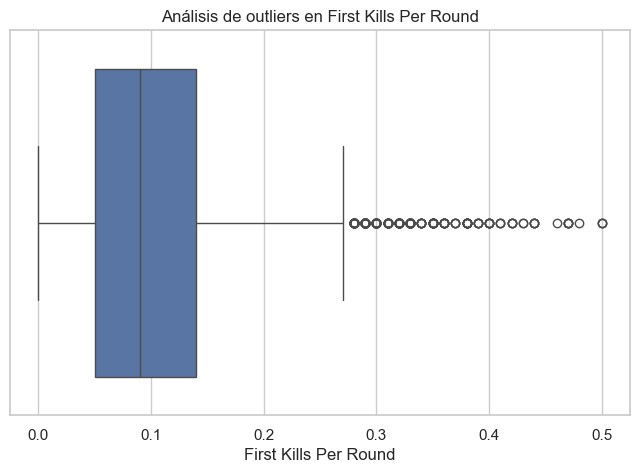

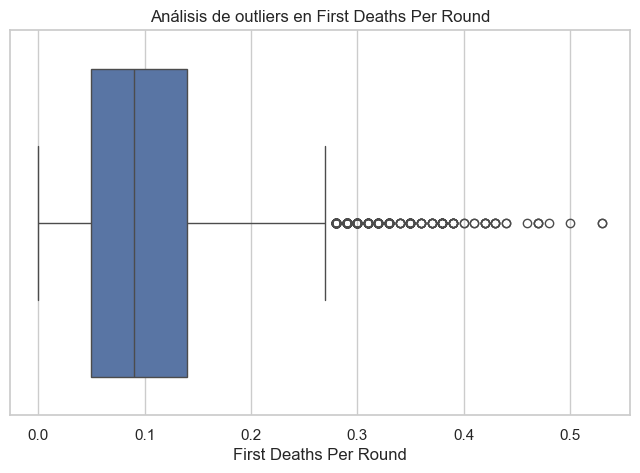

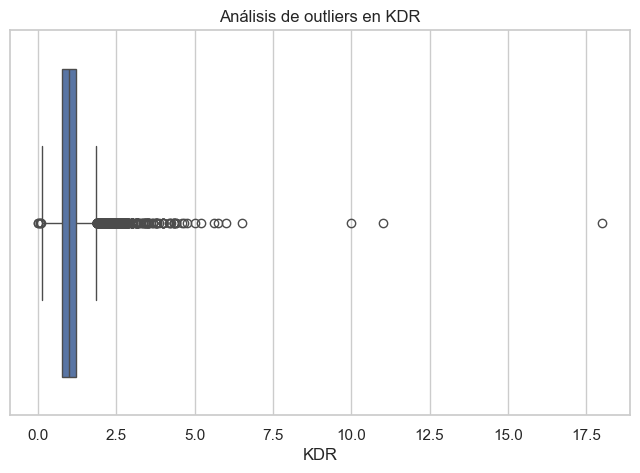

In [31]:
# Boxplots para análisis de outliers
for col in [
    "Average Combat Score",
    "Average Damage Per Round",
    "Kills Per Round",
    "First Kills Per Round",
    "First Deaths Per Round",
    "KDR"
]:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_clean, x=col)
    plt.title(f"Análisis de outliers en {col}")
    plt.xlabel(col)
    plt.show()

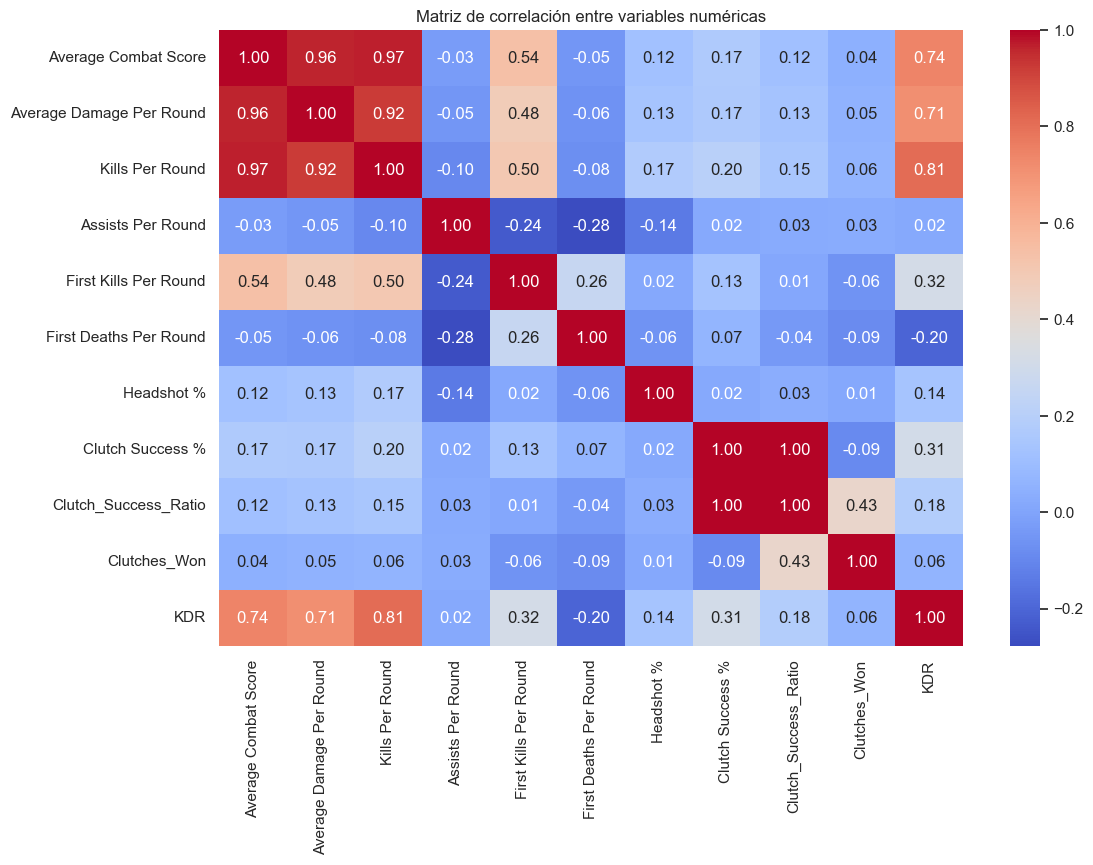

In [32]:
# Matriz de correlación
corr = df_clean[eda_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

In [33]:
# Análisis por rol
role_summary = df_clean.groupby("Role")[eda_columns].mean().round(3)
role_summary

,Average Combat Score,Average Damage Per Round,Kills Per Round,Assists Per Round,First Kills Per Round,First Deaths Per Round,Headshot %,Clutch Success %,Clutch_Success_Ratio,Clutches_Won,KDR
Role,,,,,,,,,,,
Controller,192.461,124.876,0.677,0.354,0.083,0.085,29.942,28.730,0.119,0.856,1.040
Duelist,221.420,143.090,0.780,0.187,0.171,0.165,28.269,36.538,0.108,0.490,1.109
Initiator,181.534,120.905,0.630,0.334,0.066,0.076,28.066,29.547,0.114,0.772,0.968
Sentinel,192.255,127.260,0.688,0.210,0.092,0.091,30.262,27.439,0.102,0.744,1.054


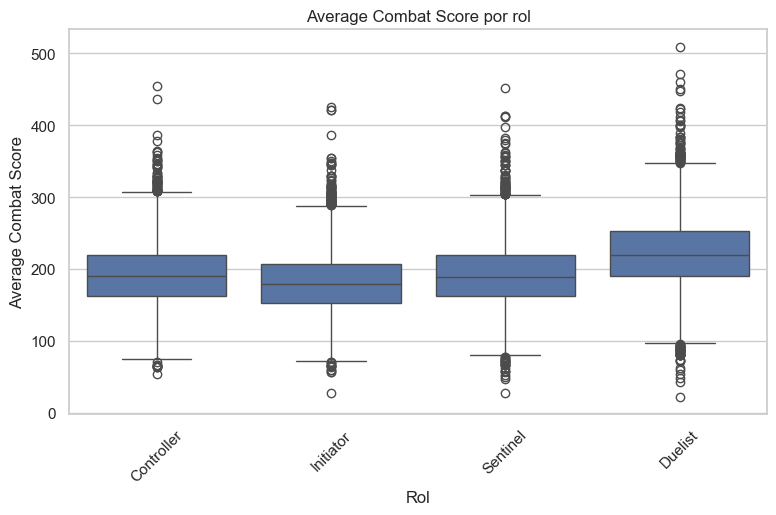

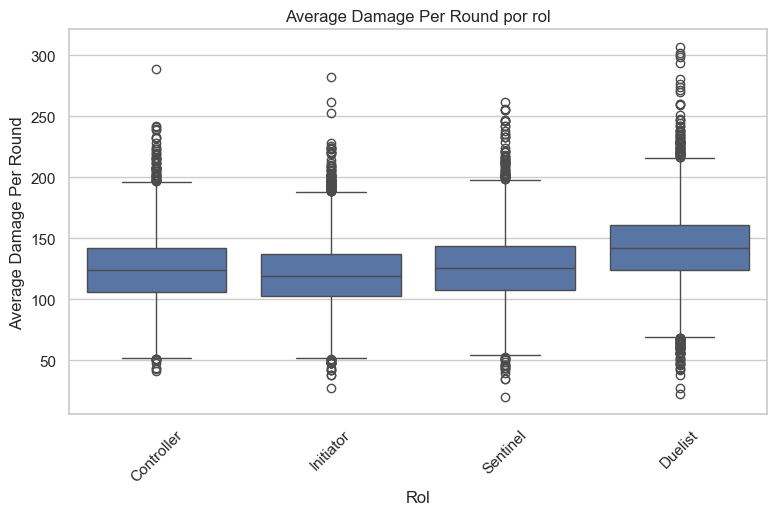

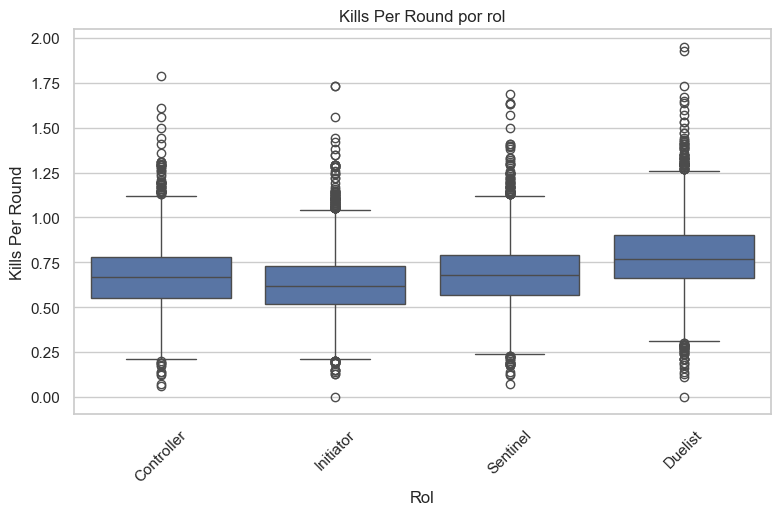

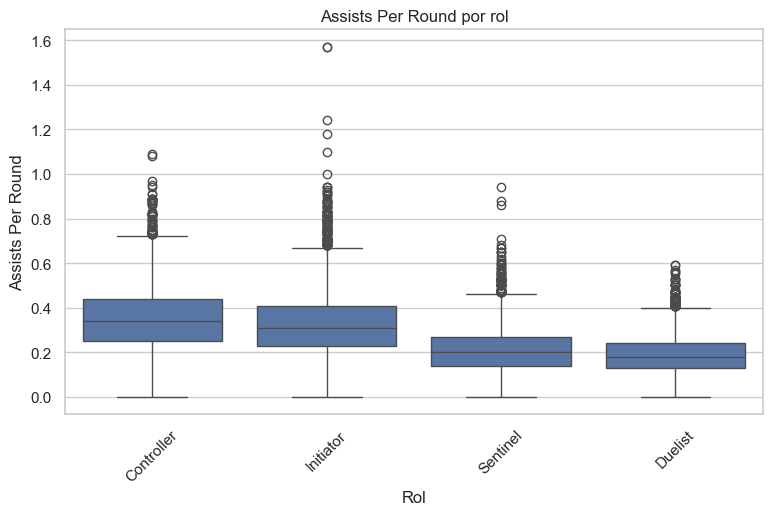

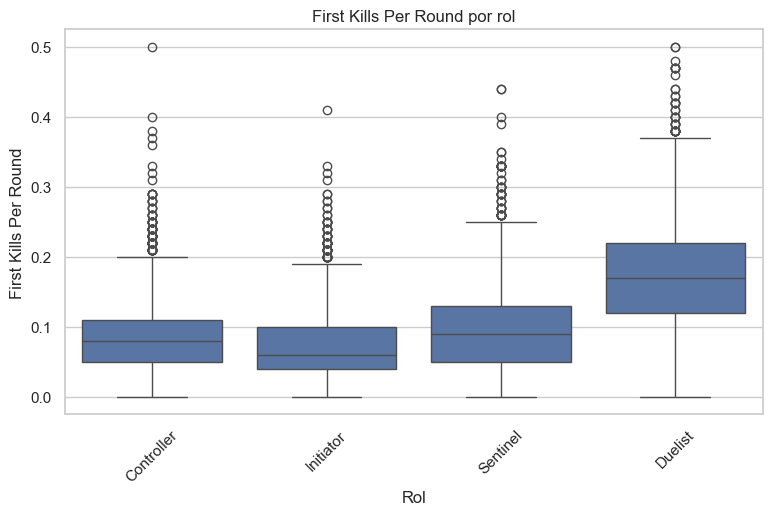

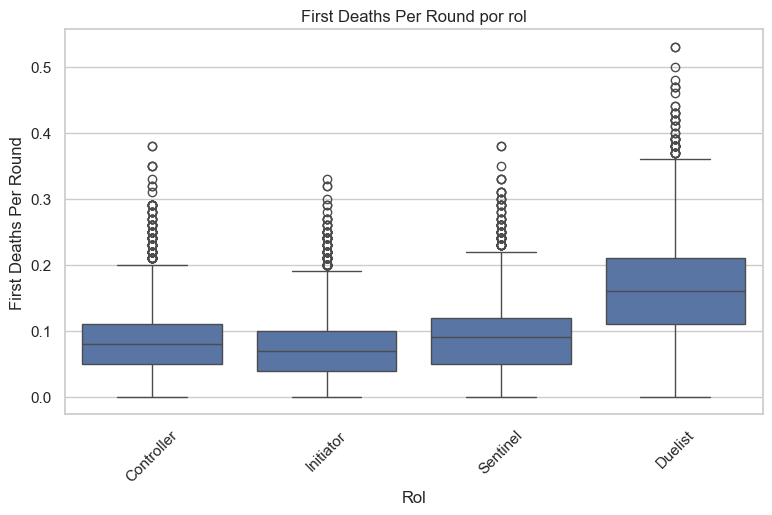

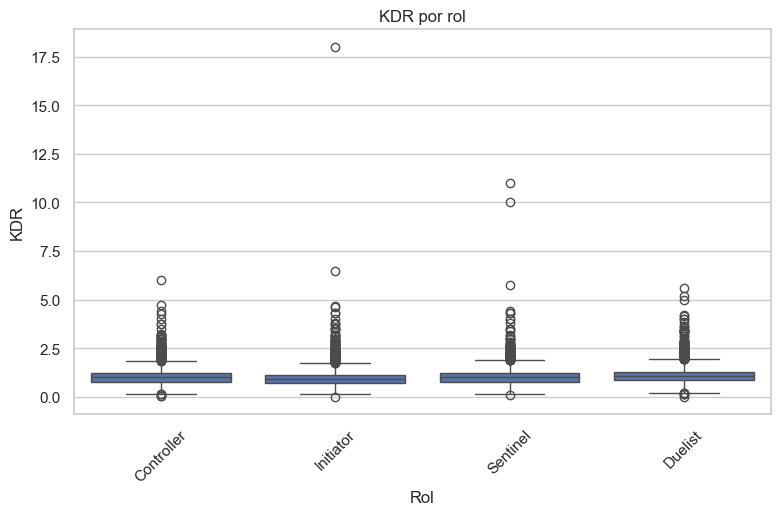

In [34]:
# Comparación de variables clave por rol
for col in [
    "Average Combat Score",
    "Average Damage Per Round",
    "Kills Per Round",
    "Assists Per Round",
    "First Kills Per Round",
    "First Deaths Per Round",
    "KDR"
]:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df_clean, x="Role", y=col)
    plt.title(f"{col} por rol")
    plt.xlabel("Rol")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.show()

### 4) DETECCIÓN DE SESGOS Y LIMITACIONES DEL DATASET

In [35]:
# Proporción de registros por rol
role_distribution_percentage = (df_clean["Role"].value_counts(normalize=True) * 100).round(2)
role_distribution_percentage

Role
Initiator     30.31
Controller    26.09
Duelist       22.59
Sentinel      21.00
Name: proportion, dtype: float64

In [36]:
# Proporción de agentes principales
agent_distribution_percentage = (df_clean["Agents"].value_counts(normalize=True) * 100).head(15).round(2)
agent_distribution_percentage

Agents
Omen         8.66
Cypher       8.05
Fade         7.66
Breach       6.95
Viper        6.40
Sova         6.19
Jett         6.00
Astra        5.71
Neon         4.89
Raze         4.61
Yoru         4.36
Killjoy      4.15
Brimstone    4.15
Vyse         3.96
Tejo         3.66
Name: proportion, dtype: float64

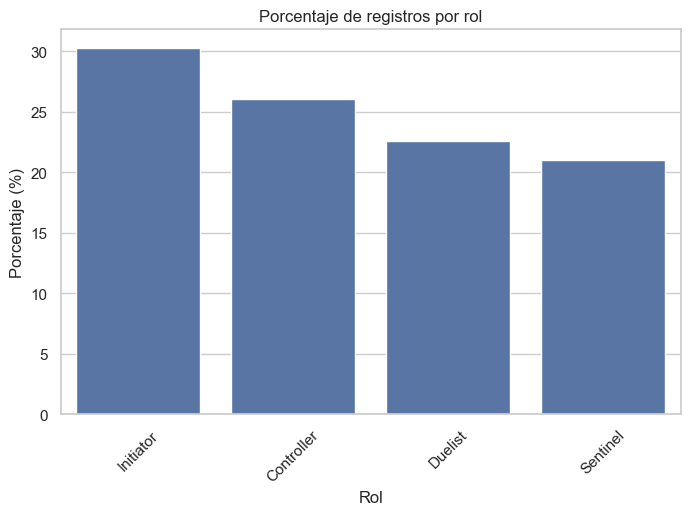

In [37]:
# Análisis de sesgo por rol
plt.figure(figsize=(8, 5))
sns.barplot(
    x=role_distribution_percentage.index,
    y=role_distribution_percentage.values
)
plt.title("Porcentaje de registros por rol")
plt.xlabel("Rol")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=45)
plt.show()

## 5. Ingenieria de Features

### 1) Variables

In [38]:
# Índices derivados para análisis del comportamiento por rol

df_clean["Offensive_Index"] = (
    df_clean["Kills Per Round"] +
    df_clean["First Kills Per Round"] +
    df_clean["Average Damage Per Round"] / df_clean["Average Damage Per Round"].max()
)

df_clean["Support_Index"] = (
    df_clean["Assists Per Round"] +
    df_clean["Clutch_Success_Ratio"]
)

df_clean["Risk_Index"] = (
    df_clean["First Deaths Per Round"] +
    (1 / (df_clean["KDR"] + 1e-6))
)

df_clean["Survival_Index"] = (
    1 - df_clean["First Deaths Per Round"]
)

df_clean["Clutch_Index"] = (
    df_clean["Clutch_Success_Ratio"] +
    df_clean["Clutches_Won"] / (df_clean["Clutches_Won"].max() + 1e-6)
)

In [39]:
df_clean[
    [
        "Offensive_Index",
        "Support_Index",
        "Risk_Index",
        "Survival_Index",
        "Clutch_Index"
    ]
].describe()

,Offensive_Index,Support_Index,Risk_Index,Survival_Index,Clutch_Index
count,16626.000000,17996.000000,1.664600e+04,16646.000000,17996.000000
mean,1.205600,0.391171,1.213758e+02,0.898188,0.137379
std,0.327864,0.250165,1.096091e+04,0.068724,0.225822
min,0.071661,0.000000,5.555555e-02,0.470000,0.000000
25%,0.985505,0.210000,9.194731e-01,0.860000,0.000000
50%,1.183225,0.340000,1.127036e+00,0.910000,0.000000
75%,1.400700,0.503333,1.397812e+00,0.950000,0.235714
max,3.117199,1.940000,1.000000e+06,1.000000,1.274510


### 2) GENERACIÓN DEL SCORE DE CUMPLIMIENTO DEL ROL

In [40]:
# Función para calcular score por rol

def calculate_role_score(row):
    role = row["Role"]

    if role == "Duelist":
        return (
            0.40 * row["First Kills Per Round"] +
            0.30 * row["Kills Per Round"] -
            0.20 * row["First Deaths Per Round"] +
            0.10 * (row["Average Damage Per Round"] / df_clean["Average Damage Per Round"].max())
        )

    elif role == "Controller":
        return (
            0.35 * row["Assists Per Round"] +
            0.25 * (row["Average Damage Per Round"] / df_clean["Average Damage Per Round"].max()) +
            0.20 * row["Kills Per Round"] -
            0.20 * row["First Deaths Per Round"]
        )

    elif role == "Sentinel":
        return (
            0.30 * row["Clutch_Success_Ratio"] +
            0.25 * (1 - row["First Deaths Per Round"]) +
            0.25 * (1 / (row["Deaths"] + 1)) +
            0.20 * row["Assists Per Round"]
        )

    elif role == "Initiator":
        return (
            0.35 * row["Assists Per Round"] +
            0.30 * row["Kills Per Round"] +
            0.20 * (row["Average Damage Per Round"] / df_clean["Average Damage Per Round"].max()) +
            0.15 * row["First Kills Per Round"]
        )

    else:
        return np.nan

In [41]:
df_clean["role_score_raw"] = df_clean.apply(calculate_role_score, axis=1)

In [42]:
# Normalización del score al rango [0,1]
score_scaler = MinMaxScaler()

df_clean["role_score"] = score_scaler.fit_transform(
    df_clean[["role_score_raw"]]
)

In [43]:
df_clean[["Role", "role_score_raw", "role_score"]].head()

,Role,role_score_raw,role_score
0,Controller,0.184976,0.236866
1,Controller,0.147788,0.196425
2,Controller,0.170261,0.220864
3,Initiator,0.447765,0.522648
4,Initiator,0.380008,0.448962


In [44]:
df_clean["role_score"].describe()

count    16631.000000
mean         0.411925
std          0.098043
min          0.000000
25%          0.346929
50%          0.401829
75%          0.470450
max          1.000000
Name: role_score, dtype: float64

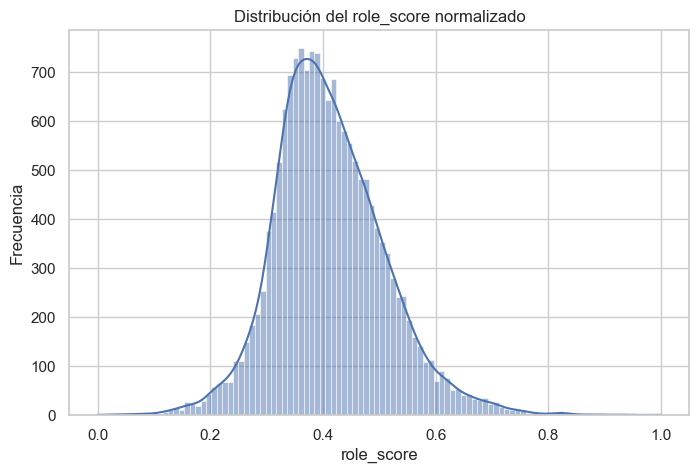

In [45]:
# Distribución del score normalizado
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["role_score"], kde=True)
plt.title("Distribución del role_score normalizado")
plt.xlabel("role_score")
plt.ylabel("Frecuencia")
plt.show()

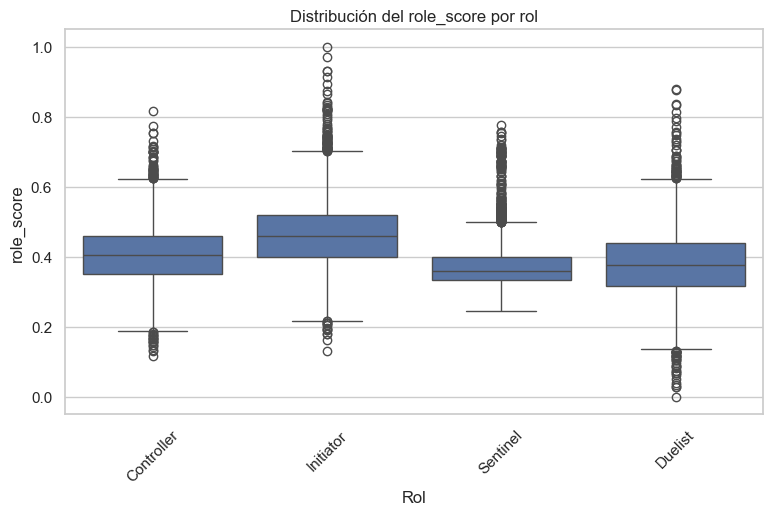

In [46]:
# Distribución del score por rol
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x="Role", y="role_score")
plt.title("Distribución del role_score por rol")
plt.xlabel("Rol")
plt.ylabel("role_score")
plt.xticks(rotation=45)
plt.show()

## 6. Selección de variables

### 1) VARIABLES PARA EL MODELADO

In [47]:
# Variables finales utilizadas para el modelado

feature_columns = [
    "Average Combat Score",
    "Average Damage Per Round",
    "Kills Per Round",
    "Assists Per Round",
    "First Kills Per Round",
    "First Deaths Per Round",
    "Headshot %",
    "Clutch Success %",
    "Clutch_Success_Ratio",
    "Clutches_Won",
    "KDR",
    "Agents",
    "Role"
]

target_column = "role_score"

In [48]:
# Dataset final para modelado
df_model = df_clean[feature_columns + [target_column]].copy()

df_model.head()

,Average Combat Score,Average Damage Per Round,Kills Per Round,Assists Per Round,First Kills Per Round,First Deaths Per Round,Headshot %,Clutch Success %,Clutch_Success_Ratio,Clutches_Won,KDR,Agents,Role,role_score
0,129.0,89.0,0.42,0.15,0.12,0.12,44.0,NaN,0.000000,0,0.611111,Astra,Controller,0.236866
1,98.0,55.0,0.32,0.26,0.05,0.26,37.0,33.0,0.333333,1,0.400000,Omen,Controller,0.196425
2,114.0,74.0,0.38,0.20,0.09,0.18,41.0,14.0,0.142857,1,0.515152,Astra,Controller,0.220864
3,219.0,147.0,0.69,0.38,0.08,0.04,23.0,33.0,0.333333,1,1.125000,Fade,Initiator,0.522648
4,220.0,142.0,0.63,0.26,0.05,0.05,28.0,NaN,0.000000,0,0.750000,Sova,Initiator,0.448962


In [49]:
# Verificación de nulos finales
df_model.isnull().sum()

Average Combat Score           10
Average Damage Per Round     1370
Kills Per Round                 0
Assists Per Round               0
First Kills Per Round        1351
First Deaths Per Round       1350
Headshot %                   1308
Clutch Success %            11337
Clutch_Success_Ratio            0
Clutches_Won                    0
KDR                             0
Agents                          0
Role                            0
role_score                   1365
dtype: int64

In [50]:
# Eliminar registros con valores nulos en variables finales
df_model = df_model.dropna().copy()

df_model.shape

(6659, 14)

### 2) ENCODING DE VARIABLES CATEGÓRICAS

In [51]:
# Encoding de variables categóricas
agent_encoder = LabelEncoder()
role_encoder = LabelEncoder()

df_model["Agents"] = agent_encoder.fit_transform(df_model["Agents"].astype(str))
df_model["Role"] = role_encoder.fit_transform(df_model["Role"].astype(str))

In [52]:
df_model.head()

,Average Combat Score,Average Damage Per Round,Kills Per Round,Assists Per Round,First Kills Per Round,First Deaths Per Round,Headshot %,Clutch Success %,Clutch_Success_Ratio,Clutches_Won,KDR,Agents,Role,role_score
1,98.0,55.0,0.32,0.26,0.05,0.26,37.0,33.0,0.333333,1,0.400000,15,0,0.196425
2,114.0,74.0,0.38,0.20,0.09,0.18,41.0,14.0,0.142857,1,0.515152,0,0,0.220864
3,219.0,147.0,0.69,0.38,0.08,0.04,23.0,33.0,0.333333,1,1.125000,7,2,0.522648
5,220.0,145.0,0.67,0.33,0.07,0.04,24.0,14.0,0.142857,1,0.937500,7,2,0.494044
6,187.0,124.0,0.60,0.13,0.13,0.09,28.0,29.0,0.285714,2,0.692308,23,0,0.305923


In [53]:
# Separación de variables predictoras y target
X = df_model[feature_columns]
y = df_model[target_column]

### 3) SELECCIÓN AUTOMÁTICA DE CARACTERÍSTICAS

In [54]:
# SelectKBest para evaluar importancia estadística de variables

selector = SelectKBest(score_func=f_regression, k=10)
selector.fit(X, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

feature_scores

,Feature,Score
10,KDR,3089.307934
0,Average Combat Score,2659.965304
2,Kills Per Round,2532.166213
1,Average Damage Per Round,2480.889865
3,Assists Per Round,1935.084403
5,First Deaths Per Round,1044.779958
8,Clutch_Success_Ratio,488.648437
7,Clutch Success %,488.609873
12,Role,213.705761
4,First Kills Per Round,65.069249


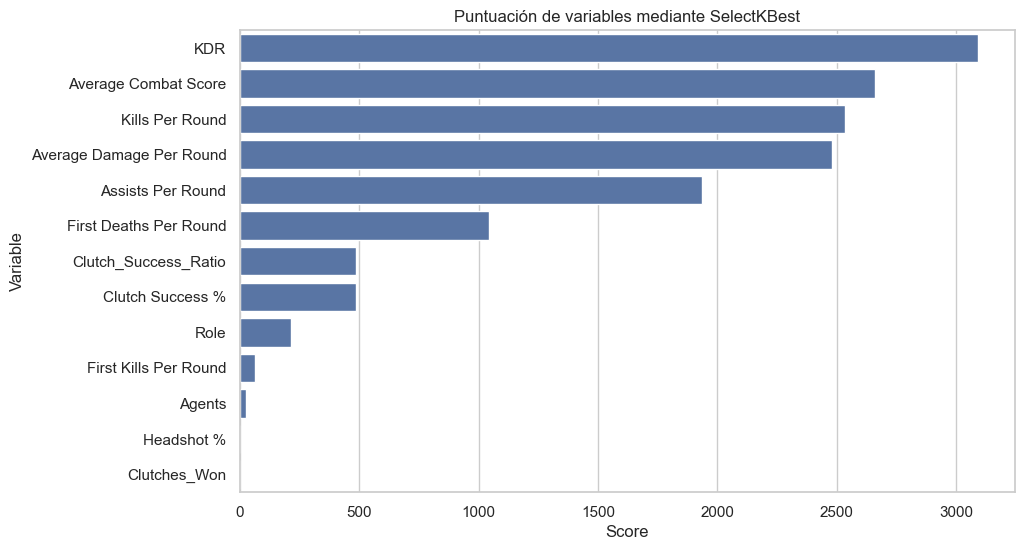

In [55]:
# Visualizar importancia estadística según SelectKBest
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_scores, x="Score", y="Feature")
plt.title("Puntuación de variables mediante SelectKBest")
plt.xlabel("Score")
plt.ylabel("Variable")
plt.show()

In [56]:
selected_features_kbest = X.columns[selector.get_support()].tolist()

print("Variables seleccionadas por SelectKBest:")
selected_features_kbest

Variables seleccionadas por SelectKBest:


['Average Combat Score',
 'Average Damage Per Round',
 'Kills Per Round',
 'Assists Per Round',
 'First Kills Per Round',
 'First Deaths Per Round',
 'Clutch Success %',
 'Clutch_Success_Ratio',
 'KDR',
 'Role']

### 4) ANÁLISIS PCA

In [57]:
# Escalado previo para PCA
standard_scaler = StandardScaler()
X_scaled = standard_scaler.fit_transform(X)

In [58]:
# Aplicar PCA
pca = PCA()
pca.fit(X_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

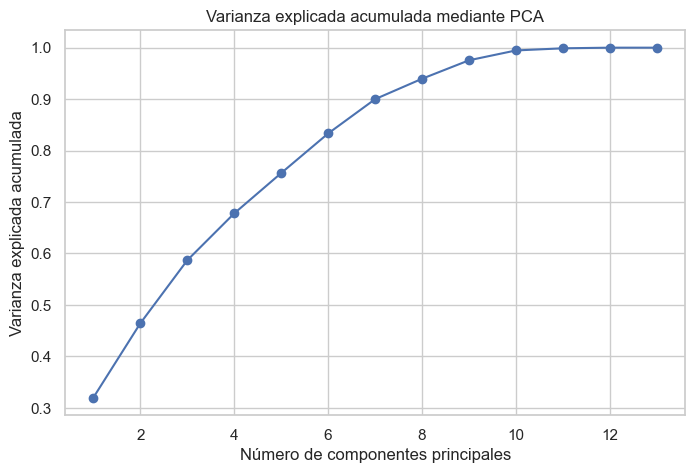

In [59]:
# Gráfica de varianza explicada acumulada
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)
plt.title("Varianza explicada acumulada mediante PCA")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.grid(True)
plt.show()

In [60]:
# Número de componentes necesarios para explicar 95% de la varianza
n_components_95 = np.argmax(explained_variance >= 0.95) + 1

print(f"Número de componentes para explicar al menos 95% de la varianza: {n_components_95}")

Número de componentes para explicar al menos 95% de la varianza: 9


In [61]:
# Crear representación PCA para análisis
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca_2[:, 0],
    "PC2": X_pca_2[:, 1],
    "Role": df_clean.loc[df_model.index, "Role"].values
})

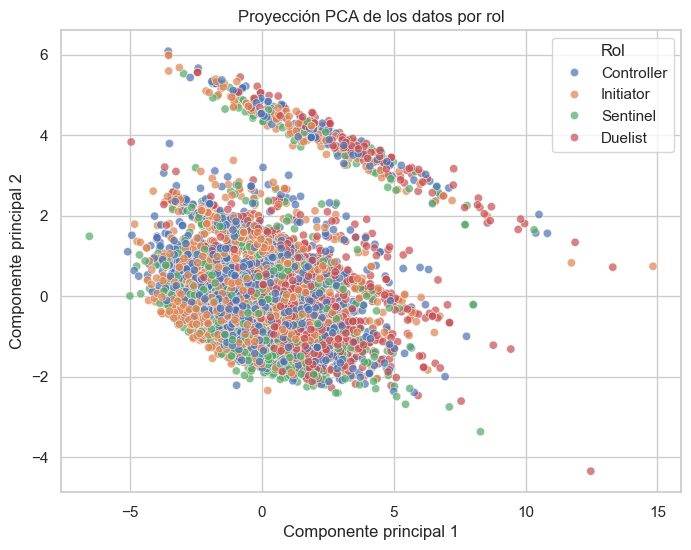

In [62]:
# Visualización en dos componentes principales
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Role", alpha=0.7)
plt.title("Proyección PCA de los datos por rol")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Rol")
plt.show()

## 7. Entrenamiento

### 1) Librerias

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

import xgboost as xgb

### 2) Variables seleccionadas por SelectKBest

In [64]:
# Variables seleccionadas automáticamente
selected_features = selected_features_kbest

print("Variables seleccionadas:")
selected_features

Variables seleccionadas:


['Average Combat Score',
 'Average Damage Per Round',
 'Kills Per Round',
 'Assists Per Round',
 'First Kills Per Round',
 'First Deaths Per Round',
 'Clutch Success %',
 'Clutch_Success_Ratio',
 'KDR',
 'Role']

In [65]:
X_selected = X[selected_features]
y_target = y.copy()

### 3) Division Train/Test

In [66]:
# División entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_target,
    test_size=0.2,
    random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (5327, 10)
Test shape: (1332, 10)


### 4) Modelos

In [67]:
models = {
    "Linear Regression": LinearRegression(),

    "KNN Regressor": KNeighborsRegressor(),

    "XGBoost Regressor": XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    )
}

### 5) Entrenamiento

In [68]:
results = []

predictions = {}

for name, model in models.items():

    print(f"\nEntrenando modelo: {name}")

    # Entrenamiento
    model.fit(X_train, y_train)

    # Predicción
    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

results_df = pd.DataFrame(results)


Entrenando modelo: Linear Regression

Entrenando modelo: KNN Regressor

Entrenando modelo: XGBoost Regressor


## 8. Evaluación

### 1) Tabla comparativa

In [69]:
# Ordenar por R2
results_df = results_df.sort_values(by="R2", ascending=False)

results_df

,Model,RMSE,MAE,R2
2,XGBoost Regressor,0.015952,0.009656,0.967357
0,Linear Regression,0.044868,0.031268,0.741759
1,KNN Regressor,0.074165,0.057280,0.294425


### 2) Visualización de métricas

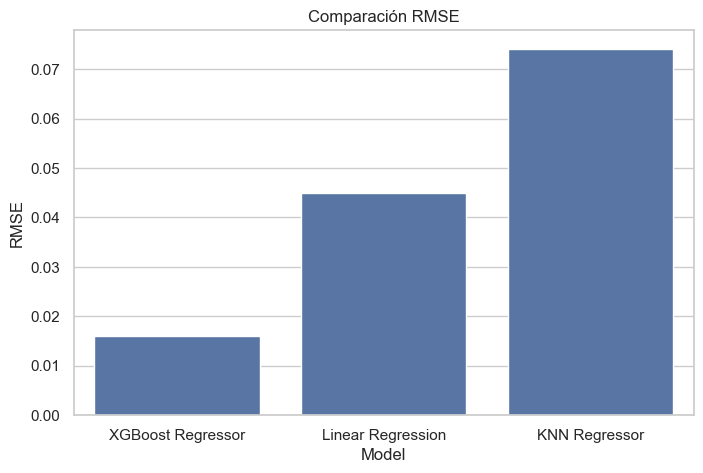

In [70]:
# RMSE
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Comparación RMSE")
plt.ylabel("RMSE")
plt.show()

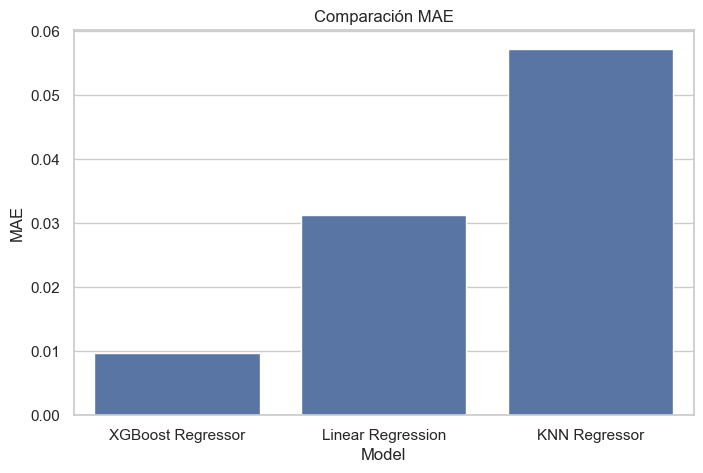

In [71]:
# MAE
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="MAE")
plt.title("Comparación MAE")
plt.ylabel("MAE")
plt.show()

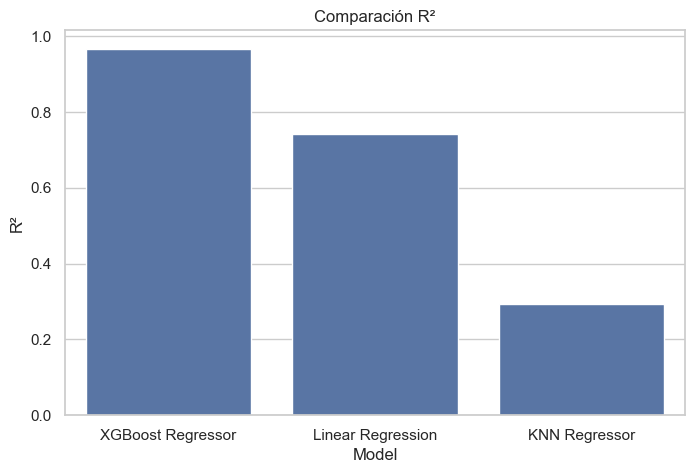

In [72]:
# R2
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="R2")
plt.title("Comparación R²")
plt.ylabel("R²")
plt.show()

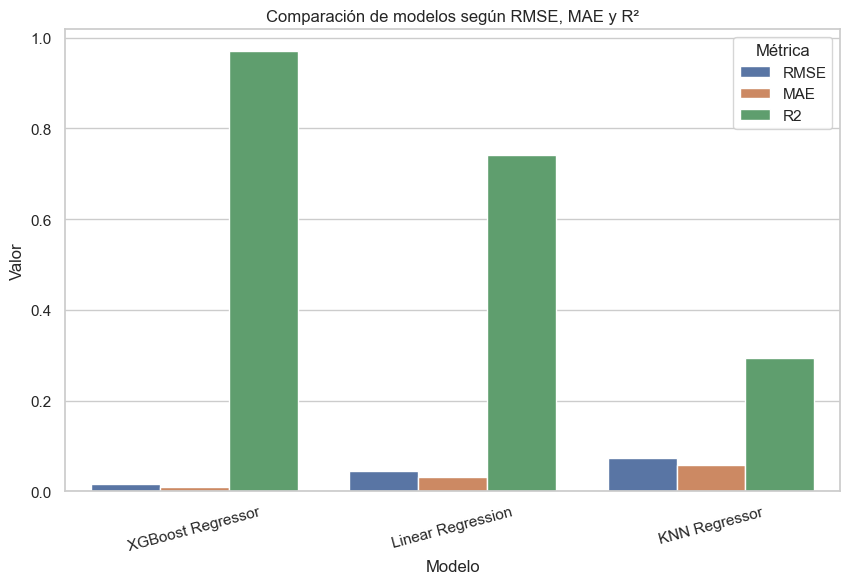

In [85]:
# Gráfico combinado de métricas
results_melted = results_df.melt(
    id_vars="Modelo",
    value_vars=["RMSE", "MAE", "R2"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_melted,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.title("Comparación de modelos según RMSE, MAE y R²")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.xticks(rotation=15)
plt.legend(title="Métrica")
plt.show()

### 3) Real vs Predicted

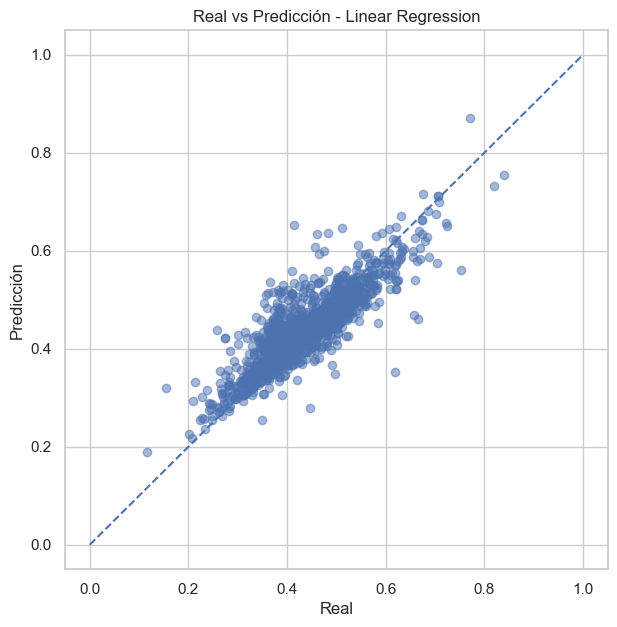

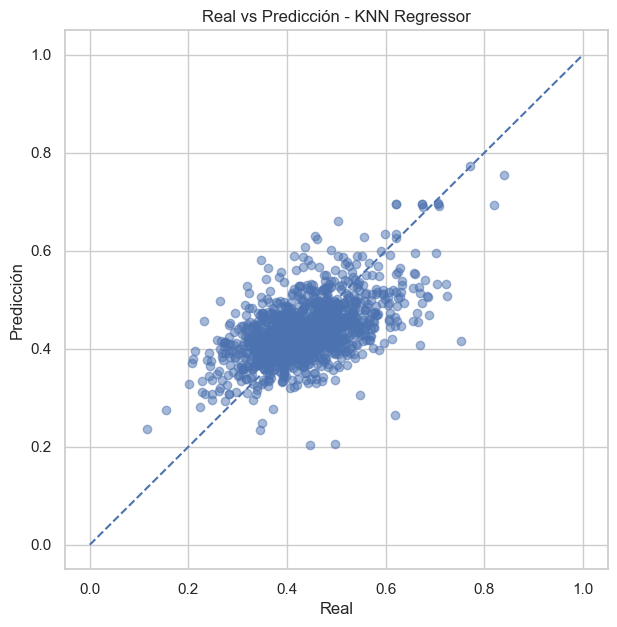

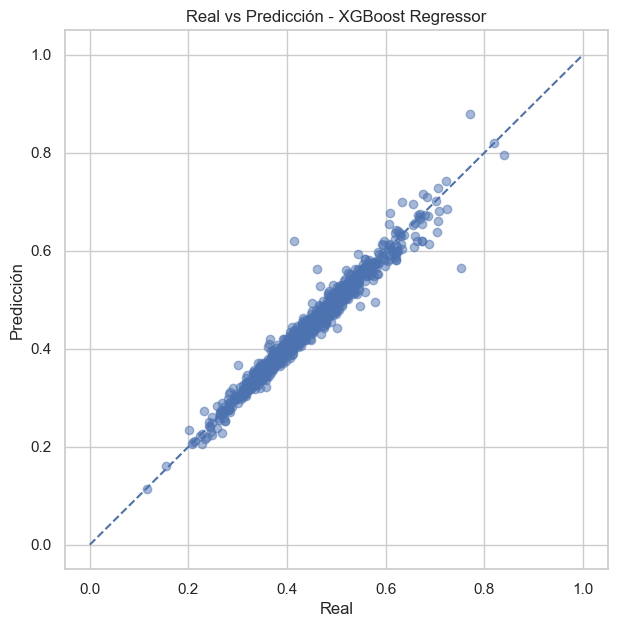

In [73]:
for model_name in predictions.keys():

    plt.figure(figsize=(7,7))

    plt.scatter(
        y_test,
        predictions[model_name],
        alpha=0.5
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--"
    )

    plt.xlabel("Real")
    plt.ylabel("Predicción")
    plt.title(f"Real vs Predicción - {model_name}")

    plt.show()

### 4) Análisis de residuos

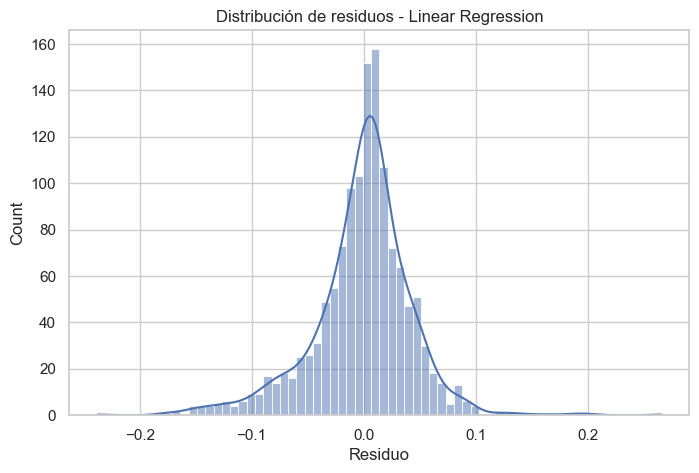

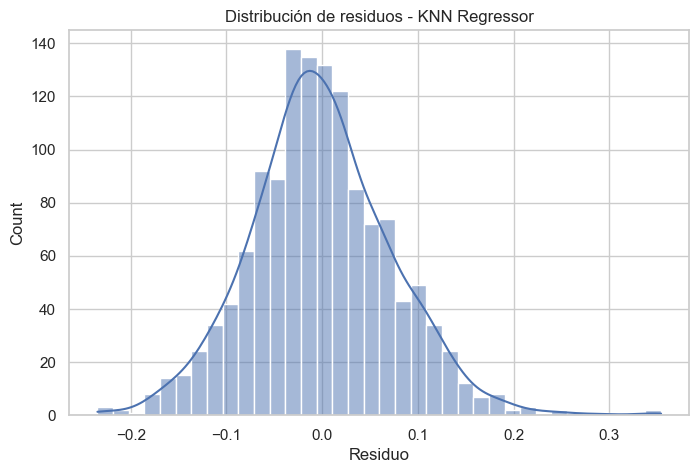

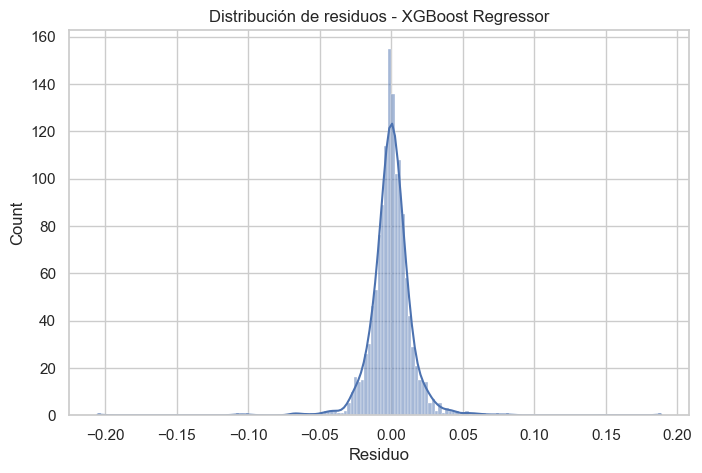

In [74]:
for model_name in predictions.keys():

    residuals = y_test - predictions[model_name]

    plt.figure(figsize=(8,5))

    sns.histplot(residuals, kde=True)

    plt.title(f"Distribución de residuos - {model_name}")
    plt.xlabel("Residuo")

    plt.show()

### 5) Optimización de Hiperparámetros

In [75]:
knn_params = {
    "n_neighbors": [3,5,7,9],
    "weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    knn_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best KNN Params:")
print(knn_grid.best_params_)

Best KNN Params:
{'n_neighbors': 9, 'weights': 'distance'}


In [76]:
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3,5,7],
    "learning_rate": [0.01, 0.05, 0.1]
}

xgb_grid = GridSearchCV(
    XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    xgb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost Params:")
print(xgb_grid.best_params_)

Best XGBoost Params:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


### 6) Modelo Final

In [77]:
best_xgb = xgb_grid.best_estimator_

best_xgb.fit(X_train, y_train)

y_pred_final = best_xgb.predict(X_test)

In [78]:
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_mae = mean_absolute_error(y_test, y_pred_final)
final_r2 = r2_score(y_test, y_pred_final)

print("FINAL MODEL METRICS")
print(f"RMSE: {final_rmse:.4f}")
print(f"MAE : {final_mae:.4f}")
print(f"R2  : {final_r2:.4f}")

FINAL MODEL METRICS
RMSE: 0.0127
MAE : 0.0080
R2  : 0.9792


### 7) Importancia de variables

In [79]:
importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
8,KDR,0.300021
3,Assists Per Round,0.170461
9,Role,0.143993
6,Clutch Success %,0.092113
2,Kills Per Round,0.083604
0,Average Combat Score,0.078129
7,Clutch_Success_Ratio,0.051171
1,Average Damage Per Round,0.035359
5,First Deaths Per Round,0.026533
4,First Kills Per Round,0.018616


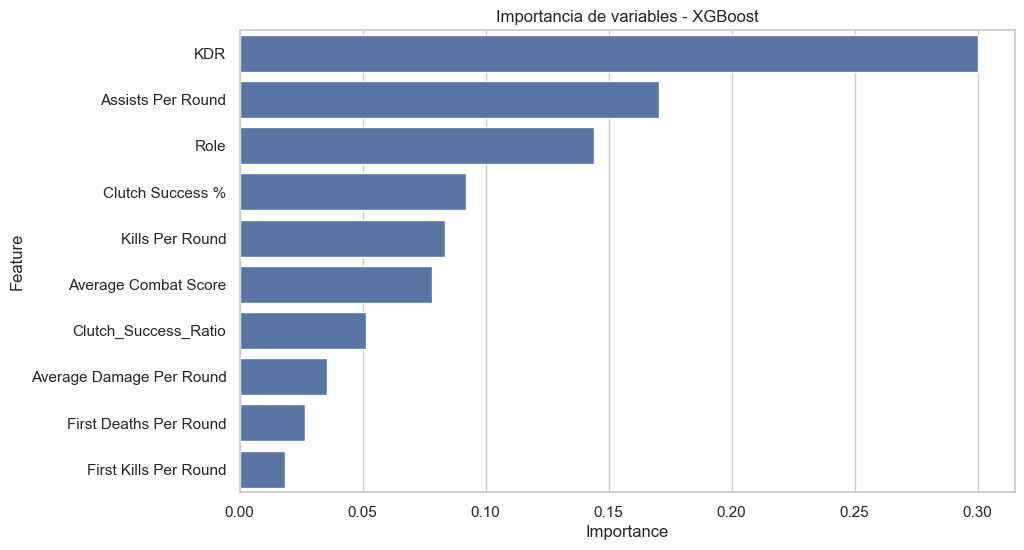

In [80]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Importancia de variables - XGBoost")

plt.show()

### 8) Análisis de errores

In [81]:
error_df = pd.DataFrame({
    "Real": y_test,
    "Predicted": y_pred_final
})

error_df["Absolute_Error"] = abs(
    error_df["Real"] - error_df["Predicted"]
)

error_df = error_df.sort_values(
    by="Absolute_Error",
    ascending=False
)

error_df.head(10)

,Real,Predicted,Absolute_Error
1336,0.414833,0.618061,0.203227
9976,0.753632,0.664720,0.088912
3222,0.771124,0.833997,0.062873
3581,0.675038,0.735245,0.060206
11521,0.633200,0.691299,0.058099
3607,0.703698,0.646442,0.057256
416,0.483098,0.540181,0.057083
16791,0.568590,0.515787,0.052803
10332,0.664501,0.612433,0.052068
12950,0.461198,0.512030,0.050832


In [86]:
# Estadísticas del error absoluto

error_stats = error_df["Absolute_Error"].describe()

error_stats

count    1332.000000
mean        0.008028
std         0.009891
min         0.000002
25%         0.002659
50%         0.005680
75%         0.010120
max         0.203227
Name: Absolute_Error, dtype: float64

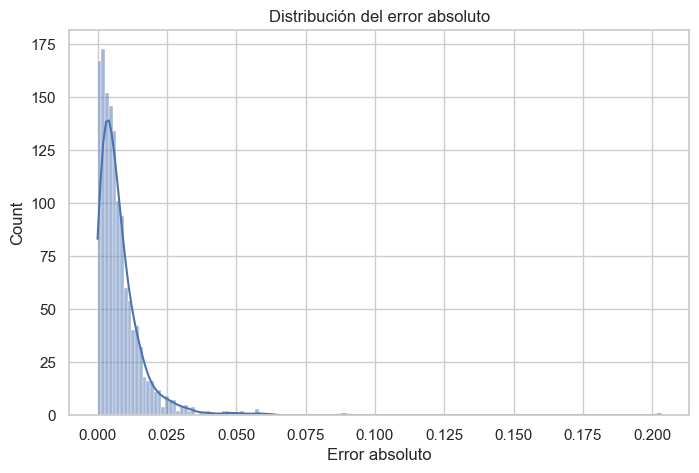

In [82]:
plt.figure(figsize=(8,5))

sns.histplot(
    error_df["Absolute_Error"],
    kde=True
)

plt.title("Distribución del error absoluto")
plt.xlabel("Error absoluto")

plt.show()

In [88]:
# Top errores

top_errors = error_df.head(10)

top_errors

,Real,Predicted,Absolute_Error
1336,0.414833,0.618061,0.203227
9976,0.753632,0.664720,0.088912
3222,0.771124,0.833997,0.062873
3581,0.675038,0.735245,0.060206
11521,0.633200,0.691299,0.058099
3607,0.703698,0.646442,0.057256
416,0.483098,0.540181,0.057083
16791,0.568590,0.515787,0.052803
10332,0.664501,0.612433,0.052068
12950,0.461198,0.512030,0.050832


In [89]:
error_analysis = X_test.copy()

error_analysis["Real"] = y_test.values
error_analysis["Predicted"] = y_pred_final
error_analysis["Absolute_Error"] = abs(
    error_analysis["Real"] - error_analysis["Predicted"]
)

error_analysis = error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
)

error_analysis.head(10)

,Average Combat Score,Average Damage Per Round,Kills Per Round,Assists Per Round,First Kills Per Round,First Deaths Per Round,Clutch Success %,Clutch_Success_Ratio,KDR,Role,Real,Predicted,Absolute_Error
1336,411.0,256.0,1.57,0.04,0.17,0.00,25.0,0.250000,2.400000,3,0.414833,0.618061,0.203227
9976,148.0,100.0,0.64,0.43,0.07,0.07,100.0,1.000000,1.800000,3,0.753632,0.664720,0.088912
3222,423.0,274.0,1.57,0.57,0.29,0.00,100.0,1.000000,3.666667,1,0.771124,0.833997,0.062873
3581,378.0,216.0,1.50,0.36,0.36,0.07,100.0,1.000000,3.500000,0,0.675038,0.735245,0.060206
11521,315.0,197.0,1.26,0.42,0.05,0.05,25.0,0.250000,2.000000,0,0.633200,0.691299,0.058099
3607,218.0,146.0,0.94,0.24,0.00,0.06,100.0,1.000000,2.285714,3,0.703698,0.646442,0.057256
416,258.0,167.0,0.95,0.55,0.18,0.00,50.0,0.500000,1.750000,1,0.483098,0.540181,0.057083
16791,151.0,76.0,0.57,0.71,0.14,0.05,33.0,0.333333,0.705882,2,0.568590,0.515787,0.052803
10332,184.0,125.0,0.61,0.28,0.00,0.17,100.0,1.000000,0.687500,3,0.664501,0.612433,0.052068
12950,344.0,218.0,1.26,0.21,0.16,0.00,30.0,0.300000,2.076923,3,0.461198,0.512030,0.050832


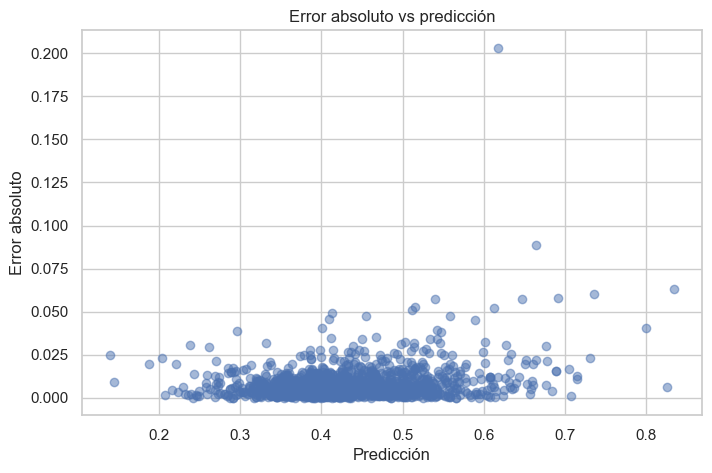

In [93]:
plt.figure(figsize=(8,5))

plt.scatter(
    error_analysis["Predicted"],
    error_analysis["Absolute_Error"],
    alpha=0.5
)

plt.xlabel("Predicción")
plt.ylabel("Error absoluto")
plt.title("Error absoluto vs predicción")

plt.show()

### 9) Análisis de errores por rol

In [90]:
# Recuperar nombres reales de roles

role_names = role_encoder.inverse_transform(
    X_test["Role"].astype(int)
)

error_analysis["Role_Name"] = role_names

In [91]:
# Error promedio por rol

role_error = error_analysis.groupby(
    "Role_Name"
)["Absolute_Error"].mean().sort_values(ascending=False)

role_error

Role_Name
Sentinel      0.008365
Initiator     0.008139
Controller    0.007907
Duelist       0.007712
Name: Absolute_Error, dtype: float64

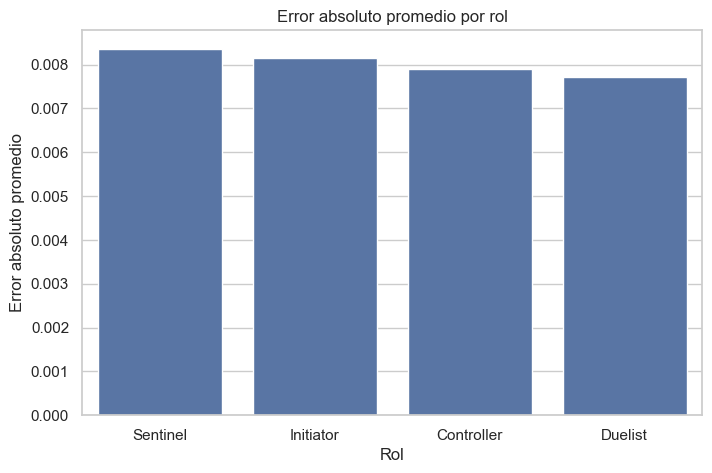

In [92]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=role_error.index,
    y=role_error.values
)

plt.title("Error absoluto promedio por rol")
plt.xlabel("Rol")
plt.ylabel("Error absoluto promedio")

plt.show()

### 9) Serialización del modelo final

In [83]:
import joblib

joblib.dump(best_xgb, "role_model.pkl")

joblib.dump(agent_encoder, "agent_encoder.pkl")

joblib.dump(role_encoder, "role_encoder.pkl")

joblib.dump(selected_features, "selected_features.pkl")

print("Modelo y artefactos guardados correctamente.")

Modelo y artefactos guardados correctamente.
